# 04 · Chemical space

What compounds actually show up in ORD reactions? This notebook looks at the most frequent reactant and product compounds and renders them with RDKit.

In [1]:
from dotenv import load_dotenv
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()

## Most frequent products

In [2]:
top_products = queries.top_compounds(engine, role="PRODUCT", limit=12)
top_products

,smiles,count
0,FC(C1=CC=C(N2CCOCC2)C=C1)(F)F,33792
1,C1(N2CCC(C3=CC=CC=C3)CC2)=CC=CN=C1,16896
2,Cl,10321
3,CC(C=C1)=C(C2=CC=C(N=CC=C3)C3=C2)C4=C1N(C5OCCC...,5760
4,Cn1cnc(C#N)c1-c1ccccc1F,2008
5,N#CC1=C(C2=CC=CC=C2F)N(C)C=N1,1984
6,N,1468
7,OC1=C(O)C(CC=C)=CC=C1CC=C,1227
8,OC1=C(O)C(CC=C)=C(CC=C)C=C1,1227
9,[Cl-],1010


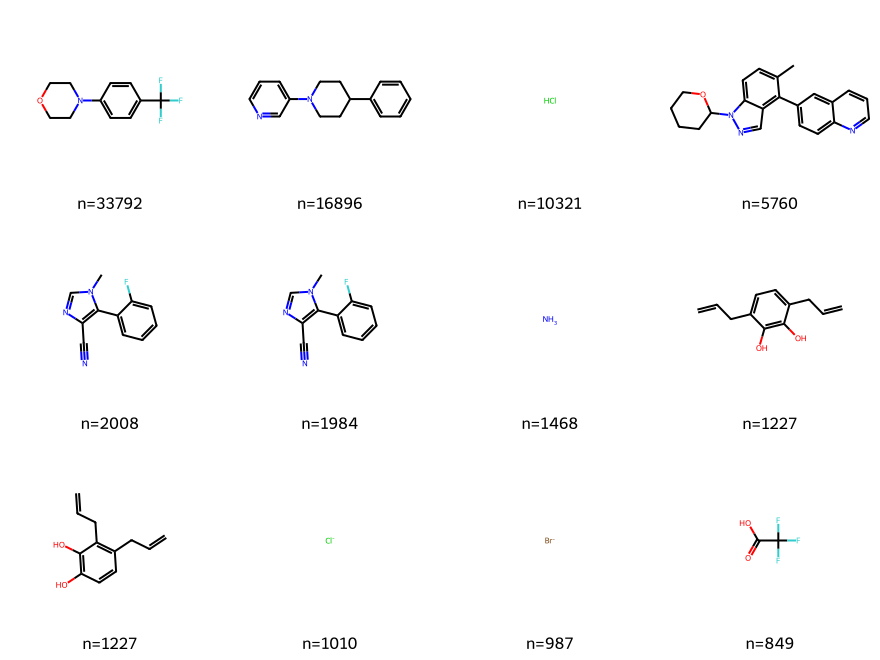

In [3]:
mols = [Chem.MolFromSmiles(s) for s in top_products["smiles"]]
legends = [f"n={c}" for c in top_products["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)

## Scaffold diversity

A quick look at how many distinct Bemis-Murcko scaffolds these top products reduce to -- a cheap proxy for how structurally diverse (vs. how repetitive/analog-series-like) the most common products are.

In [4]:
def murcko_scaffold_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))

top_products["scaffold"] = top_products["smiles"].map(murcko_scaffold_smiles)
n_scaffolds = top_products["scaffold"].nunique()
print(f"{n_scaffolds} distinct scaffolds among the top {len(top_products)} products")

6 distinct scaffolds among the top 12 products
